# Comparing Performance of TGradAMI vs. TGrad (for EVI and Rainfall data).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Import from local directory
import sys
import random

sys.path.insert(0, '../src')
from TemporalGP.TGP.tgrad_ami import TGradAMI
from TemporalGP.TGP.t_graank import TGrad
from TemporalGP.utils import classify_ftgps

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



Configure TGradAMI algorithm hyperparameters.

In [2]:
# Hyperparameters

# f_path = "../datasets/air_quality1k.csv"
# f_path = "../datasets/air_quality25.csv"

f_path_evi = "../datasets/ke_evi_data_2k.csv"
f_path_rain = "../datasets/ke_rain_data_2k.csv"

eq = False
min_sup = 0.1
tgt_col = 1
tgt_cols = [1, 2, 3, 4]
min_rep = 0.75
mi_err_margin = 0.0001
eval_mode = True
clustering_method = False

Visualize the top 5 rows of the dataset.

In [3]:
rain_data = pd.read_csv(f_path_rain)
evi_data = pd.read_csv(f_path_evi)


print(rain_data.head())
print("\n")
print(evi_data.head())

  Date (Jul-Sep)   NRB (mm)   KAK (mm)   MAK (mm)   WAJ (mm)
0        07-2000   22.01000   526.8000      18.45  12.219990
1        07-2001   57.55001   539.0801       0.90  13.440000
2        07-2002   45.17000   349.2700      20.47  15.320000
3        07-2003   77.08001   660.0199       2.27   8.940001
4        07-2004   16.48000   424.6999       0.71   4.819999


  Date (Jul-Sep)   NRB (EVI)   KAK (EVI)   MAK (EVI)   WAJ (EVI)
0        07-2000    0.094866    0.401556    0.160511    0.120766
1        07-2001    0.236884    0.417010    0.183184    0.152754
2        07-2002    0.243191    0.370047    0.206061    0.109228
3        07-2003    0.202896    0.423199    0.159602    0.109228
4        07-2004    0.119559    0.378931    0.178707    0.099040


Initialize TGrad and TGradAMI algorithms by creating objects for different target columns.

In [4]:
rain_tgrads_ami = []
evi_tgrads_ami = []
rain_tgrads_rnd = []
evi_tgrads_rnd = []
for t_col in tgt_cols:
    t_grad_rain = TGradAMI(f_path_rain, min_sup, eq, target_col=t_col, min_rep=min_rep, min_error=mi_err_margin)
    t_grad_evi = TGradAMI(f_path_evi, min_sup, eq, target_col=t_col, min_rep=min_rep, min_error=mi_err_margin)
    t_grad_rain_rnd = TGradAMI(f_path_rain, min_sup, eq, target_col=t_col, min_rep=min_rep, min_error=mi_err_margin)
    t_grad_evi_rnd = TGradAMI(f_path_evi, min_sup, eq, target_col=t_col, min_rep=min_rep, min_error=mi_err_margin)

    rain_tgrads_ami.append(t_grad_rain)
    evi_tgrads_ami.append(t_grad_evi)
    rain_tgrads_rnd.append(t_grad_rain_rnd)
    evi_tgrads_rnd.append(t_grad_evi_rnd)


rain_tgrads = []
evi_tgrads = []
for t_col in tgt_cols:
    t_grad_rain = TGrad(f_path_rain, min_sup, eq, target_col=t_col, min_rep=min_rep)
    t_grad_evi = TGrad(f_path_evi, min_sup, eq, target_col=t_col, min_rep=min_rep)

    rain_tgrads.append(t_grad_rain)
    evi_tgrads.append(t_grad_evi)

Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok


Run the algorithm for mining FTGPs (Fuzzy Temporal Gradual Patterns) in evaluation mode. The algorithm returns a number of results in a dict format.

In [5]:
for i, t_grad_rain in enumerate(rain_tgrads_ami):
    eval_dict_rain = t_grad_rain.discover_tgp(use_clustering=clustering_method, eval_mode=eval_mode)
    transform_steps = eval_dict_rain['Transformation Steps']
    eval_dict_evi = evi_tgrads_ami[i].discover_tgp(use_clustering=clustering_method, transformation_steps=transform_steps, eval_mode=eval_mode)


In [6]:
for i in range(len(rain_tgrads_rnd)):
    transform_steps = {}
    random.seed(int(i)*42)
    for j in rain_tgrads_rnd[i].feature_cols:
        # random.seed(int(j)*24)
        transform_steps.update({int(j): random.randint(1, rain_tgrads_rnd[i].max_step)})
    # print(transform_steps)
    eval_dict_rain = rain_tgrads_rnd[i].discover_tgp(use_clustering=clustering_method, transformation_steps=transform_steps, eval_mode=eval_mode)
    eval_dict_evi = evi_tgrads_rnd[i].discover_tgp(use_clustering=clustering_method, transformation_steps=transform_steps, eval_mode=eval_mode)

In [7]:
for i in range(len(rain_tgrads)):
    rain_tgrads[i].discover_tgp()
    evi_tgrads[i].discover_tgp()


* Tabulate the mined FTGPs with their corresponding parameters

## TGradAMI FTGPs

In [8]:
patterns = [t_grad_rain.display_patterns_as_df for t_grad_rain in rain_tgrads_ami]  # Collect all patterns into a list
res_rain_df = pd.concat(patterns, ignore_index=True)  # Combine them in one go
res_rain_df.head()

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (mm)+, (KAK (mm)+) +12.0 months",0.458,0.277,6.014,3.797,1,2.97
1,"NRB (mm)+, (KAK (mm)-) +12.0 months",0.542,0.328,6.602,4.338,1,3.084
2,"NRB (mm)+, (MAK (mm)+) +5.0 years",0.444,0.269,6.897,4.548,1,3.219
3,"NRB (mm)+, (MAK (mm)-) +5.0 years",0.549,0.332,5.917,3.668,1,3.386
4,"NRB (mm)+, (WAJ (mm)+) +12.0 months",0.379,0.229,6.034,3.629,1,2.853


In [9]:
patterns = [t_grad_evi.display_patterns_as_df for t_grad_evi in evi_tgrads_ami]  # Collect all patterns into a list
res_evi_df = pd.concat(patterns, ignore_index=True)  # Combine them in one go
res_evi_df.head()

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (EVI)+, (KAK (EVI)+) +12.0 months",0.49,0.296,6.427,4.103,1,3.625
1,"NRB (EVI)+, (KAK (EVI)-) +12.0 months",0.51,0.308,6.244,4.114,1,3.628
2,"NRB (EVI)+, (MAK (EVI)+) +5.0 years",0.477,0.289,6.562,4.432,1,3.077
3,"NRB (EVI)+, (MAK (EVI)-) +5.0 years",0.523,0.316,6.125,3.779,1,3.131
4,"NRB (EVI)+, (WAJ (EVI)+) +12.0 months",0.418,0.253,5.516,3.836,1,2.435


## TGrad FTGPs

In [10]:
patterns = [t_grad_rain.display_patterns_as_df for t_grad_rain in rain_tgrads]
res_rain_df2 = pd.concat(patterns, ignore_index=True)
res_rain_df2.head()

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (mm)+, (KAK (mm)+) +12.0 months",0.476,0.435,7.882,5.182,1,1.571
1,"NRB (mm)+, (KAK (mm)-) +12.0 months",0.524,0.478,7.471,4.929,1,1.511
2,"NRB (mm)+, (MAK (mm)+) +12.0 months",0.463,0.423,8.037,5.311,1,2.602
3,"NRB (mm)+, (MAK (mm)-) +12.0 months",0.532,0.486,7.382,4.804,1,2.434
4,"NRB (mm)+, (WAJ (mm)+) +12.0 months",0.368,0.336,7.024,4.563,1,1.903


In [11]:
patterns = [t_grad_evi.display_patterns_as_df for t_grad_evi in evi_tgrads]
res_evi_df2 = pd.concat(patterns, ignore_index=True)
res_evi_df2.head()

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (EVI)+, (KAK (EVI)+) +12.0 months",0.463,0.423,7.346,4.892,1,2.303
1,"NRB (EVI)+, (KAK (EVI)-) +12.0 months",0.537,0.49,7.944,5.176,1,2.113
2,"NRB (EVI)+, (MAK (EVI)+) +12.0 months",0.519,0.474,7.667,5.134,1,2.165
3,"NRB (EVI)+, (MAK (EVI)-) +12.0 months",0.481,0.439,7.667,4.969,1,2.267
4,"NRB (EVI)+, (WAJ (EVI)+) +12.0 months",0.433,0.395,6.89,4.656,1,1.584


## TGrad AMI FTGPs (with random transformation steps)


In [12]:
patterns = [t_grad_rain.display_patterns_as_df for t_grad_rain in rain_tgrads_rnd]  # Collect all patterns into a list
res_rain_df3 = pd.concat(patterns, ignore_index=True)  # Combine them in one go
res_rain_df3.head()

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (mm)+, (KAK (mm)+) +4.0 years",0.462,0.312,7.038,4.646,1,2.46
1,"NRB (mm)+, (KAK (mm)-) +4.0 years",0.538,0.364,6.348,4.044,1,2.554
2,"NRB (mm)+, (MAK (mm)+) +4.0 years",0.556,0.375,6.6,4.3,1,2.844
3,"NRB (mm)+, (MAK (mm)-) +4.0 years",0.439,0.296,6.8,4.409,1,2.745
4,"NRB (mm)+, (WAJ (mm)+) +12.0 months",0.386,0.261,6.379,3.98,1,2.67


In [13]:
patterns = [t_grad_evi.display_patterns_as_df for t_grad_evi in evi_tgrads_rnd]  # Collect all patterns into a list
res_evi_df3 = pd.concat(patterns, ignore_index=True)  # Combine them in one go
res_evi_df3.head()

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (EVI)+, (KAK (EVI)+) +4.0 years",0.579,0.391,7.101,4.642,1,2.906
1,"NRB (EVI)+, (KAK (EVI)-) +4.0 years",0.421,0.285,6.069,3.824,1,2.822
2,"NRB (EVI)+, (MAK (EVI)+) +4.0 years",0.515,0.348,7.205,4.503,1,2.609
3,"NRB (EVI)+, (MAK (EVI)-) +4.0 years",0.485,0.328,6.096,4.097,1,2.578
4,"NRB (EVI)+, (WAJ (EVI)+) +12.0 months",0.427,0.289,6.068,4.253,1,2.173


## Compute recall, precision and F1 score of extracted FTGPs

In [14]:
tgrad_ami_lst_pat_rain = []
for tgrad in rain_tgrads_ami:
    tgrad_ami_lst_pat_rain.extend(tgrad.gradual_patterns)

tgrad_ami_lst_pat_evi = []
for tgrad in evi_tgrads_ami:
    tgrad_ami_lst_pat_evi.extend(tgrad.gradual_patterns)

tgrad_lst_pat_rain = []
for tgrad in rain_tgrads:
    tgrad_lst_pat_rain.extend(tgrad.gradual_patterns)

tgrad_lst_pat_evi = []
for tgrad in evi_tgrads:
    tgrad_lst_pat_evi.extend(tgrad.gradual_patterns)

tgrad_rnd_lst_pat_rain = []
for tgrad in rain_tgrads_rnd:
    tgrad_rnd_lst_pat_rain.extend(tgrad.gradual_patterns)

tgrad_rnd_lst_pat_evi = []
for tgrad in evi_tgrads_rnd:
    tgrad_rnd_lst_pat_evi.extend(tgrad.gradual_patterns)

* True Positive (TP): an FTGP that appears in both **Rain** and **EVI** datasets with support >= 0.5
* False Positive (FP): an FTGP that appears in **Rain** dataset with support >= 0.5 but appears in **EVI** dataset with support < 0.5
* False Negative (FN): an FTGP that appears in **Rain** dataset with support < 0.5 but appears in **EVI** dataset with support >= 0.5
* True Negative (TN): an FTGP that appears in both **Rain** and **EVI** datasets with support < 0.5

In [15]:
res_tgrad_ami = classify_ftgps(tgrad_ami_lst_pat_rain, tgrad_ami_lst_pat_evi)
res_tgrad_rnd = classify_ftgps(tgrad_rnd_lst_pat_rain, tgrad_rnd_lst_pat_evi)
res_tgrad = classify_ftgps(tgrad_lst_pat_rain, tgrad_lst_pat_evi)


print(f"TGradAMI: {res_tgrad_ami}")
print(f"TGradAMI-Random: {res_tgrad_rnd}")
print(f"TGrad: {res_tgrad}")

TGradAMI: {'TP': 7, 'FP': 3, 'FN': 5, 'TN': 49}
TGradAMI-Random: {'TP': 10, 'FP': 12, 'FN': 2, 'TN': 42}
TGrad: {'TP': 46, 'FP': 56, 'FN': 27, 'TN': 273}


<Figure size 800x500 with 0 Axes>

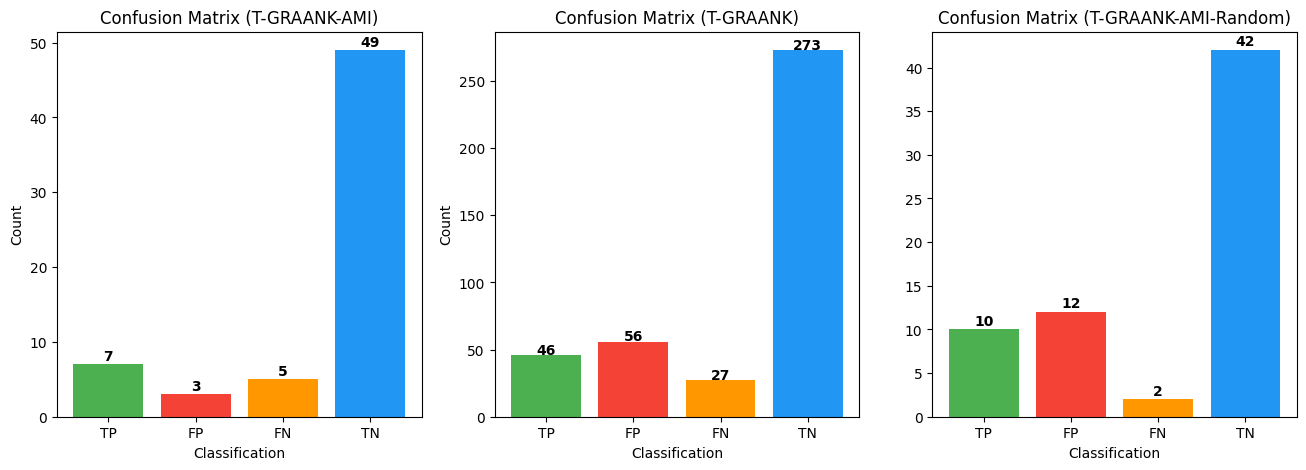

In [16]:
cat_tgrad_ami = list(res_tgrad_ami.keys())
cat_tgrad_rnd = list(res_tgrad_rnd.keys())
cat_tgrad = list(res_tgrad.keys())
vals_tgrad_ami = list(res_tgrad_ami.values())
vals_tgrad_rnd = list(res_tgrad_rnd.values())
vals_tgrad = list(res_tgrad.values())

# Create plot
plt.figure(figsize=(8, 5))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4CAF50', '#F44336', '#FF9800', '#2196F3'] # Green, Red, Orange, Blue
ax1.bar(cat_tgrad_ami, vals_tgrad_ami, color=colors)
ax2.bar(cat_tgrad, vals_tgrad, color=colors)
ax3.bar(cat_tgrad_rnd, vals_tgrad_rnd, color=colors)

# Add styling
ax1.set_title('Confusion Matrix (T-GRAANK-AMI)')
ax1.set_xlabel('Classification')
ax1.set_ylabel('Count')
ax2.set_title('Confusion Matrix (T-GRAANK)')
ax2.set_xlabel('Classification')
ax2.set_ylabel('Count')
ax3.set_title('Confusion Matrix (T-GRAANK-AMI-Random)')
ax3.set_xlabel('Classification')

# Add value labels on top of bars
for i, v in enumerate(vals_tgrad_ami):
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

for i, v in enumerate(vals_tgrad):
    ax2.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

for i, v in enumerate(vals_tgrad_rnd):
    ax3.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.show()

In [17]:
def compute_performance(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return round(precision, 3), round(recall,3), round(f1,3)

In [18]:
tgrad_ami_pre, tgrad_ami_rec, tgrad_ami_f1 = compute_performance(res_tgrad_ami["TP"], res_tgrad_ami["FP"], res_tgrad_ami["FN"])
tgrad_rnd_pre, tgrad_rnd_rec, tgrad_rnd_f1 = compute_performance(res_tgrad_rnd["TP"], res_tgrad_rnd["FP"], res_tgrad_rnd["FN"])
tgrad_pre, tgrad_rec, tgrad_f1 = compute_performance(res_tgrad["TP"], res_tgrad["FP"], res_tgrad["FN"])

print(f"TGradAMI\nPrecision: {tgrad_ami_pre}, Recall: {tgrad_ami_rec}, F1: {tgrad_ami_f1}\n")
print(f"TGradAMI-Random\nPrecision: {tgrad_rnd_pre}, Recall: {tgrad_rnd_rec}, F1: {tgrad_rnd_f1}\n")
print(f"TGrad\nPrecision: {tgrad_pre}, Recall: {tgrad_rec}, F1: {tgrad_f1}")

TGradAMI
Precision: 0.7, Recall: 0.583, F1: 0.636

TGradAMI-Random
Precision: 0.455, Recall: 0.833, F1: 0.588

TGrad
Precision: 0.451, Recall: 0.63, F1: 0.526
